In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier 
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import warnings as wr
wr.filterwarnings('ignore')

In [2]:
df = pd.read_csv('cancer dataset.csv')

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df = df.drop(['id','Unnamed: 32'], axis = 'columns')

In [6]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


<AxesSubplot:xlabel='diagnosis', ylabel='count'>

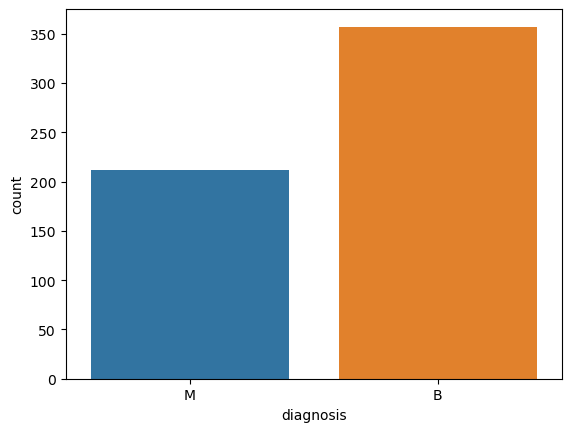

In [7]:
sns.countplot(x='diagnosis',data=df)

In [8]:
df.diagnosis.value_counts()

B    357
M    212
Name: diagnosis, dtype: int64

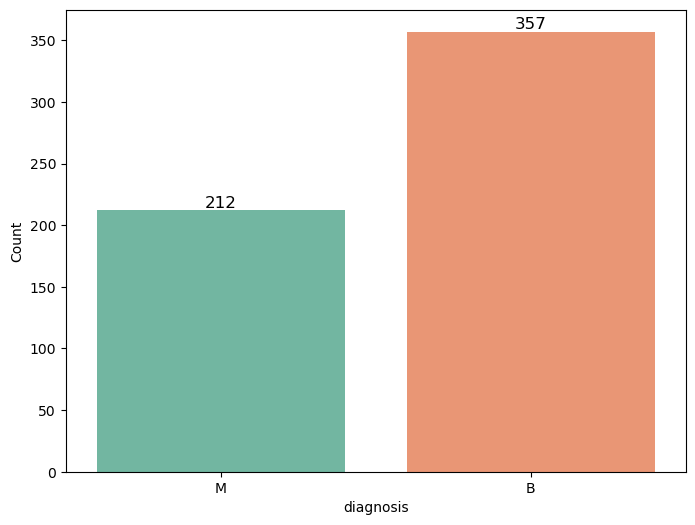

In [9]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='diagnosis', data=df, palette='Set2')

for p in ax.patches: # Annotate the bars with their respective counts
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom', fontsize=12)

#set the y-axis label
plt.ylabel('Count')

plt.show()


In [10]:
x = df.drop('diagnosis',axis=1)

In [11]:
y = df[['diagnosis']]

In [12]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [13]:
pd.DataFrame(y).head()

,0
0,1
1,1
2,1
3,1
4,1


In [14]:
pd.DataFrame(y).tail()

,0
564,1
565,1
566,1
567,1
568,0


# Train Test Split

Train = 70% <br>
Test = 15% <br>
Tuning = 15%

In [15]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, random_state=42, test_size=.30)

In [16]:
ytest

array([0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0])

In [17]:
ytest.shape

(171,)

In [18]:
xtest.shape

(171, 30)

# Test and Validation

In [19]:
x_test, x_val, y_test, y_val = train_test_split(xtest, ytest, random_state=42, test_size=.50)
x_test.shape # 15% of total data

(85, 30)

In [20]:
x_val.shape # 15% of total data ; for hyper param tuning

(86, 30)

# Step 3: Decision Tree model and evaluation

In [21]:
dt_model = DecisionTreeClassifier(random_state=1)
dt_model.fit(xtrain, ytrain)
y_pred_dt = dt_model.predict(xtest)

In [22]:
y_pred_dt

array([0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

# Evaluate Decision Tree model performance

In [23]:
print("Decision Tree Model Performance:")
print("Accuracy:", accuracy_score(ytest, y_pred_dt), '\n')
print("Classification Report:")
print(classification_report(ytest, y_pred_dt))

Decision Tree Model Performance:
Accuracy: 0.935672514619883 

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       108
           1       0.89      0.94      0.91        63

    accuracy                           0.94       171
   macro avg       0.93      0.94      0.93       171
weighted avg       0.94      0.94      0.94       171



# Step 4: Random Forest model and evaluation

In [24]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(xtrain, ytrain)
y_pred_rf = rf_model.predict(xtest)

In [25]:
y_pred_rf

array([0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

# Evaluate Random Forest model performance

In [26]:
print("\nRandom Forest Model Performance:") 
print("Accuracy:", accuracy_score(ytest, y_pred_rf), '\n') 
print("Classification Report:") 
print(classification_report(ytest, y_pred_rf)) 


Random Forest Model Performance:
Accuracy: 0.9707602339181286 

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       108
           1       0.98      0.94      0.96        63

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



In [ ]:
# StackingClassifier: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html

# Pre - Pruning for Cost Complexity

# Initialized Hyperparameters

In [27]:
dt_params = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None,2,4,6,8,10,12, 15, 17,20,22,25,28],
    'min_samples_split': [2,3,4,5,6,7,8,9,10],
    'min_samples_leaf': [1,2,3,4,5]
}

min_samples_split → minimum people needed to consider dividing team

min_samples_leaf → minimum people allowed in each final team

In [28]:
rf_params = {
    'n_estimators': [65, 101, 125, 151, 175, 201, 225, 251, 301],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 2,4,6,8,10,12, 15, 17,20,22,25,28],
    'min_samples_split': [2,3,4,5,6,7,8,10],
    'min_samples_leaf': [1, 2, 3, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Perform Grid Search for Decision Tree

In [29]:
dt_grid_search = GridSearchCV(estimator = DecisionTreeClassifier(random_state=42),
                              param_grid = dt_params, cv=5)
dt_grid_search.fit(xtrain, ytrain)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 2, 4, 6, 8, 10, 12, 15, 17, 20, 22,
                                       25, 28],
                         'min_samples_leaf': [1, 2, 3, 4, 5],
                         'min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'splitter': ['best', 'random']})

In [30]:
dt_grid_search.cv_results_ 

{'mean_fit_time': array([0.00543418, 0.00176058, 0.00445375, ..., 0.00140166, 0.00450997,
        0.00151453]),
 'std_fit_time': array([0.00048036, 0.00068687, 0.00022971, ..., 0.00048882, 0.00043794,
        0.0007914 ]),
 'mean_score_time': array([0.0008029 , 0.00081835, 0.00130281, ..., 0.00080113, 0.00059919,
        0.00110116]),
 'std_score_time': array([0.00040145, 0.00041038, 0.00040036, ..., 0.00040059, 0.00048924,
        0.00020152]),
 'param_criterion': masked_array(data=['gini', 'gini', 'gini', ..., 'entropy', 'entropy',
                    'entropy'],
              mask=[False, False, False, ..., False, False, False],
        fill_value='?',
             dtype=object),
 'param_max_depth': masked_array(data=[None, None, None, ..., 28, 28, 28],
              mask=[False, False, False, ..., False, False, False],
        fill_value='?',
             dtype=object),
 'param_min_samples_leaf': masked_array(data=[1, 1, 1, ..., 5, 5, 5],
              mask=[False, False, False, ..

In [31]:
tuning_result_dt_gs = pd.DataFrame(dt_grid_search.cv_results_)
tuning_result_dt_gs.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.005434,0.000480,0.000803,0.000401,gini,None,1,2,best,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.9125,0.8875,0.9000,0.936709,0.911392,0.909620,0.016292,1867
1,0.001761,0.000687,0.000818,0.000410,gini,None,1,2,random,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.9375,0.9000,0.9625,0.911392,0.949367,0.932152,0.023284,400
2,0.004454,0.000230,0.001303,0.000400,gini,None,1,3,best,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.9125,0.8875,0.9000,0.936709,0.911392,0.909620,0.016292,1867
3,0.002004,0.000634,0.001100,0.000489,gini,None,1,3,random,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.9500,0.9000,0.9625,0.924051,0.949367,0.937184,0.022400,54
4,0.006381,0.001086,0.001339,0.000424,gini,None,1,4,best,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.9125,0.8875,0.9000,0.936709,0.924051,0.912152,0.017321,1645


In [ ]:
tuning_result_dt_gs.shape  ## total 2340 bar dt train hoise

(2340, 18)

In [33]:
dt_grid_search.best_params_ #clf = dt_grid_search.best_params_

{'criterion': 'entropy',
 'max_depth': 6,
 'min_samples_leaf': 1,
 'min_samples_split': 9,
 'splitter': 'random'}

In [34]:
tuning_result_dt_gs.sort_values('rank_test_score').head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1455,0.001402,0.000492,0.001028,5.338775e-05,entropy,6,1,9,random,"{'criterion': 'entropy', 'max_depth': 6, 'min_...",0.9375,0.9500,0.9375,0.949367,0.936709,0.942215,0.006108,1
1473,0.001430,0.000528,0.001102,3.747294e-04,entropy,6,2,9,random,"{'criterion': 'entropy', 'max_depth': 6, 'min_...",0.9375,0.9375,0.9500,0.949367,0.936709,0.942215,0.006108,1
1743,0.001902,0.000492,0.001000,6.503192e-07,entropy,12,2,9,random,"{'criterion': 'entropy', 'max_depth': 12, 'min...",0.9375,0.9250,0.9500,0.949367,0.936709,0.939715,0.009267,3
1203,0.001500,0.000447,0.001308,4.104168e-04,entropy,None,2,9,random,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.9375,0.9250,0.9500,0.949367,0.936709,0.939715,0.009267,3
1384,0.004787,0.000548,0.001217,5.321061e-04,entropy,4,2,10,best,"{'criterion': 'entropy', 'max_depth': 4, 'min_...",0.9375,0.9000,0.9750,0.949367,0.936709,0.939715,0.024205,3


# Perform Grid Search for Random Forest

rf_grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                              param_grid=rf_params, cv=5)
rf_grid_search.fit(xtrain, ytrain)

# Evaluate the optimized models

In [35]:
y_pred_dt_gs = dt_grid_search.predict(xtest)
print("\nDecision Tree Grid Search Performance:")
print("Accuracy:", accuracy_score(ytest, y_pred_dt_gs))
print("Classification Report:")
print(classification_report(ytest, y_pred_dt_gs))


Decision Tree Grid Search Performance:
Accuracy: 0.9473684210526315
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       108
           1       0.95      0.90      0.93        63

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



# Random Forest Grid Search
y_pred_rf_gs = rf_grid_search.predict(xtest)
print("\nRandom Forest Grid Search Performance:")
print("Accuracy:", accuracy_score(ytest, y_pred_rf_gs))
print("Classification Report:")
print(classification_report(ytest, y_pred_rf_gs))


# Hyperparameter optimization using Randomized Search for Decision Tree

In [36]:
rf_params

{'n_estimators': [65, 101, 125, 151, 175, 201, 225, 251, 301],
 'criterion': ['gini', 'entropy'],
 'max_depth': [None, 2, 4, 6, 8, 10, 12, 15, 17, 20, 22, 25, 28],
 'min_samples_split': [2, 3, 4, 5, 6, 7, 8, 10],
 'min_samples_leaf': [1, 2, 3, 4],
 'max_features': ['auto', 'sqrt', 'log2']}

In [37]:
dt_random_search = RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=42), 
                                      param_distributions=dt_params, n_iter=1000, cv=5, random_state=42) 
dt_random_search.fit(xtrain, ytrain) 

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=1000,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [None, 2, 4, 6, 8, 10, 12,
                                                      15, 17, 20, 22, 25, 28],
                                        'min_samples_leaf': [1, 2, 3, 4, 5],
                                        'min_samples_split': [2, 3, 4, 5, 6, 7,
                                                              8, 9, 10],
                                        'splitter': ['best', 'random']},
                   random_state=42)

In [38]:
dt_random_search.cv_results_

{'mean_fit_time': array([0.00451078, 0.00120111, 0.00544705, 0.00519519, 0.00141492,
        0.00476685, 0.00160265, 0.00135479, 0.00447807, 0.00501943,
        0.00177603, 0.00419617, 0.00170197, 0.0046607 , 0.00110326,
        0.00147352, 0.00524263, 0.00150185, 0.00526195, 0.00190268,
        0.00180092, 0.00146136, 0.00120192, 0.00150189, 0.00141292,
        0.0013072 , 0.00146861, 0.00470653, 0.00509133, 0.00472288,
        0.00358896, 0.0008019 , 0.00271306, 0.00410767, 0.00160213,
        0.00120063, 0.0015007 , 0.00447941, 0.00481811, 0.0032526 ,
        0.00376525, 0.00145168, 0.00471191, 0.00417938, 0.00429296,
        0.00417643, 0.00520992, 0.00160756, 0.00507388, 0.00480886,
        0.00140085, 0.00471072, 0.00120111, 0.00462241, 0.00367837,
        0.00419836, 0.00382771, 0.00354033, 0.00491734, 0.00515304,
        0.00291958, 0.00210338, 0.00140209, 0.00223475, 0.00180106,
        0.00170207, 0.00562663, 0.0014082 , 0.00159945, 0.00482812,
        0.00512576, 0.00200243,

In [39]:
tuning_result_dt_rs = pd.DataFrame(dt_random_search.cv_results_)
tuning_result_dt_rs.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_splitter,param_min_samples_split,param_min_samples_leaf,param_max_depth,param_criterion,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004511,0.000836,0.001221,0.000772,best,3,3,4,gini,"{'splitter': 'best', 'min_samples_split': 3, '...",0.9375,0.9000,0.9250,0.949367,0.924051,0.927184,0.016444,331
1,0.001201,0.000401,0.000824,0.000415,random,5,2,15,entropy,"{'splitter': 'random', 'min_samples_split': 5,...",0.9250,0.8875,0.9125,0.898734,0.873418,0.899430,0.018133,902
2,0.005447,0.001205,0.001624,0.000512,best,4,3,15,entropy,"{'splitter': 'best', 'min_samples_split': 4, '...",0.9250,0.8875,0.9250,0.949367,0.924051,0.922184,0.019805,460
3,0.005195,0.000680,0.001469,0.000488,best,7,2,10,gini,"{'splitter': 'best', 'min_samples_split': 7, '...",0.9375,0.9000,0.9375,0.949367,0.924051,0.929684,0.016867,194
4,0.001415,0.000506,0.000819,0.000411,random,7,2,None,entropy,"{'splitter': 'random', 'min_samples_split': 7,...",0.9375,0.8875,0.9125,0.949367,0.898734,0.917120,0.023203,641


In [40]:
dt_random_search.best_params_

{'splitter': 'random',
 'min_samples_split': 9,
 'min_samples_leaf': 2,
 'max_depth': 8,
 'criterion': 'entropy'}

In [41]:
y_pred_dt_gs = dt_random_search.predict(xtest)
print("\nDecision Tree Grid Search Performance:")
print("Accuracy:", accuracy_score(ytest, y_pred_dt_gs))
print("Classification Report:")
print(classification_report(ytest, y_pred_dt_gs))


Decision Tree Grid Search Performance:
Accuracy: 0.9590643274853801
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       108
           1       0.92      0.97      0.95        63

    accuracy                           0.96       171
   macro avg       0.95      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



# Perform Randomized Search for Random Forest

In [42]:
rf_random_search = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
                                      param_distributions=rf_params, n_iter=100, cv=5, random_state=42)
rf_random_search.fit(xtrain, ytrain)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=100,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [None, 2, 4, 6, 8, 10, 12,
                                                      15, 17, 20, 22, 25, 28],
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': [1, 2, 3, 4],
                                        'min_samples_split': [2, 3, 4, 5, 6, 7,
                                                              8, 10],
                                        'n_estimators': [65, 101, 125, 151, 175,
                                                         201, 225, 251, 301]},
                   random_state=42)

In [43]:
rf_random_search.cv_results_
tuning_result_rf_rs = pd.DataFrame(rf_random_search.cv_results_)
tuning_result_rf_rs

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_min_samples_leaf,param_max_features,param_max_depth,param_criterion,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.000201,0.000403,0.000000,0.000000,65,5,4,auto,10,entropy,"{'n_estimators': 65, 'min_samples_split': 5, '...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,60
1,0.211617,0.004517,0.010845,0.000504,201,10,4,log2,None,gini,"{'n_estimators': 201, 'min_samples_split': 10,...",0.9500,0.95,0.9625,0.936709,0.936709,0.947184,0.009694,43
2,0.000200,0.000400,0.000000,0.000000,301,8,3,auto,12,gini,"{'n_estimators': 301, 'min_samples_split': 8, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,60
3,0.140427,0.007060,0.007228,0.000514,125,7,4,log2,25,entropy,"{'n_estimators': 125, 'min_samples_split': 7, ...",0.9500,0.95,0.9625,0.936709,0.949367,0.949715,0.008160,28
4,0.160053,0.003025,0.008341,0.000576,151,3,3,log2,None,entropy,"{'n_estimators': 151, 'min_samples_split': 3, ...",0.9750,0.95,0.9625,0.936709,0.936709,0.952184,0.014904,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.000282,0.000563,0.000000,0.000000,125,2,2,auto,12,gini,"{'n_estimators': 125, 'min_samples_split': 2, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,60
96,0.257875,0.004063,0.011304,0.000494,225,6,2,sqrt,28,entropy,"{'n_estimators': 225, 'min_samples_split': 6, ...",0.9625,0.95,0.9625,0.949367,0.949367,0.954747,0.006335,5
97,0.178003,0.005904,0.009505,0.000346,175,6,2,log2,15,gini,"{'n_estimators': 175, 'min_samples_split': 6, ...",0.9375,0.95,0.9625,0.936709,0.949367,0.947215,0.009495,35
98,0.186395,0.004100,0.009849,0.001184,175,5,2,sqrt,None,gini,"{'n_estimators': 175, 'min_samples_split': 5, ...",0.9875,0.95,0.9500,0.949367,0.949367,0.957247,0.015129,1


In [44]:
rf_random_search.best_params_

{'n_estimators': 151,
 'min_samples_split': 3,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 15,
 'criterion': 'gini'}

# Evaluate the optimized models for Randomized Search

# Decision Tree Randomized Search

In [45]:
y_pred_dt_rs = dt_random_search.predict(xtest)
print("\n Decision Tree Randomized Search Performance:")
print("Accuracy:", accuracy_score(ytest, y_pred_dt_rs))
print("Classification Report:")
print(classification_report(ytest, y_pred_dt_rs))


 Decision Tree Randomized Search Performance:
Accuracy: 0.9590643274853801
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       108
           1       0.92      0.97      0.95        63

    accuracy                           0.96       171
   macro avg       0.95      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



# Random Forest Randomized Search

In [46]:
y_pred_rf_rs = rf_random_search.predict(xtest)
print("\n Random Forest Randomized Search Performance:")
print("Accuracy:", accuracy_score(ytest, y_pred_rf_rs))
print("Classification Report:")
print(classification_report(ytest, y_pred_rf_rs))


 Random Forest Randomized Search Performance:
Accuracy: 0.9707602339181286
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       108
           1       0.98      0.94      0.96        63

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



# Post Pruning for Decision Tree

In [47]:
dt_clf = dt_random_search.best_estimator_
dt_clf

DecisionTreeClassifier(criterion='entropy', max_depth=8, min_samples_leaf=2,
                       min_samples_split=9, random_state=42, splitter='random')

[Text(0.4431818181818182, 0.9444444444444444, 'concave points_mean <= 0.04\nentropy = 0.954\nsamples = 398\nvalue = [249, 149]'),
 Text(0.18181818181818182, 0.8333333333333334, 'radius_worst <= 17.727\nentropy = 0.248\nsamples = 218\nvalue = [209, 9]'),
 Text(0.13636363636363635, 0.7222222222222222, 'concave points_mean <= 0.02\nentropy = 0.161\nsamples = 213\nvalue = [208, 5]'),
 Text(0.09090909090909091, 0.6111111111111112, 'entropy = 0.0\nsamples = 96\nvalue = [96, 0]'),
 Text(0.18181818181818182, 0.6111111111111112, 'radius_se <= 0.623\nentropy = 0.255\nsamples = 117\nvalue = [112, 5]'),
 Text(0.13636363636363635, 0.5, 'perimeter_mean <= 79.994\nentropy = 0.176\nsamples = 114\nvalue = [111, 3]'),
 Text(0.09090909090909091, 0.3888888888888889, 'entropy = 0.0\nsamples = 52\nvalue = [52, 0]'),
 Text(0.18181818181818182, 0.3888888888888889, 'compactness_se <= 0.013\nentropy = 0.28\nsamples = 62\nvalue = [59, 3]'),
 Text(0.13636363636363635, 0.2777777777777778, 'concavity_worst <= 0.214

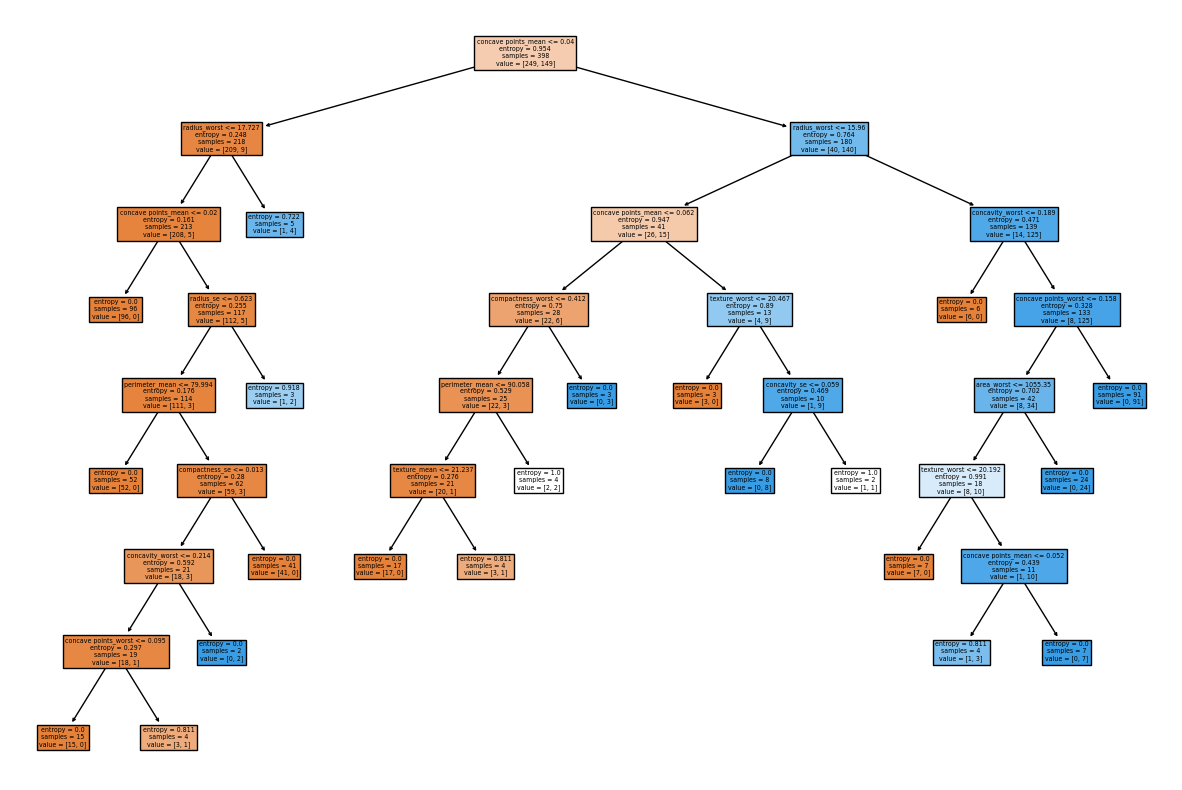

In [48]:
plt.figure(figsize=(15,10))
tree.plot_tree(dt_clf, filled=True, feature_names = x.columns)

[Read Docs](https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html)

In [49]:
pruning_path = dt_clf.cost_complexity_pruning_path(xtrain, ytrain) # clf = DecisionTreeClassifier  
ccp_alpha_values = pruning_path.ccp_alphas 

In [50]:
ccp_alpha_values 

array([0.        , 0.00399335, 0.00604739, 0.00641958, 0.00675868,
       0.00862793, 0.01202884, 0.01435018, 0.0173026 , 0.01763119,
       0.03099137, 0.03549229, 0.04094249, 0.05496803, 0.08343007,
       0.47242814])

In [51]:
clfs_list = []  # save models with diffrent ccp_alpha value
for ccp in ccp_alpha_values:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp)
    clf.fit(xtrain, ytrain)
    clfs_list.append(clf)

In [52]:
clfs_list 

[DecisionTreeClassifier(random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.003993352659045518, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.006047387516658223, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.006419576589874848, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.006758683256012092, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.00862793379793314, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.012028844403926979, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.014350184435176862, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.017302601474775314, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.01763119048807507, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.030991367208617764, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.03549229443392196, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.04094249107720667, random_state=42),
 DecisionTreeClassifier(ccp_alpha=0.05496803084950469, random_state=42),
 

In [53]:
train_scores = [ clf.score(xtrain, ytrain) for clf in clfs_list ] 
test_scores = [ clf.score(xtest, ytest) for clf in clfs_list ] 

In [54]:
train_scores

[1.0,
 0.992462311557789,
 0.9899497487437185,
 0.9874371859296482,
 0.9874371859296482,
 0.9824120603015075,
 0.9698492462311558,
 0.9698492462311558,
 0.9422110552763819,
 0.9422110552763819,
 0.9246231155778895,
 0.9246231155778895,
 0.9246231155778895,
 0.9246231155778895,
 0.9246231155778895,
 0.6256281407035176]

In [55]:
test_scores

[0.9415204678362573,
 0.9590643274853801,
 0.9649122807017544,
 0.9649122807017544,
 0.9649122807017544,
 0.9649122807017544,
 0.9590643274853801,
 0.9590643274853801,
 0.9298245614035088,
 0.9298245614035088,
 0.8947368421052632,
 0.8947368421052632,
 0.8947368421052632,
 0.8947368421052632,
 0.8947368421052632,
 0.631578947368421]

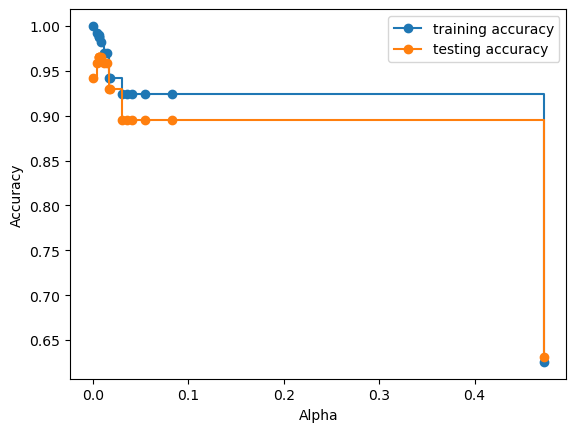

In [56]:
fig, ax = plt.subplots()
ax.set_xlabel("Alpha")
ax.set_ylabel("Accuracy")

ax.plot(ccp_alpha_values, train_scores, marker='o', label="training accuracy", drawstyle="steps-post")
ax.plot(ccp_alpha_values, test_scores, marker='o', label="testing accuracy", drawstyle="steps-post")
ax.legend()

In [57]:
clf = DecisionTreeClassifier(random_state=42, ccp_alpha=0.01)
clf.fit(xtrain, ytrain)

DecisionTreeClassifier(ccp_alpha=0.01, random_state=42)

In [58]:
pred = clf.predict(xtest)
accuracy_score(ytest, pred)

0.9649122807017544

In [59]:
clf.score(xtrain, ytrain)

0.9824120603015075

[Text(0.4230769230769231, 0.9, 'concave points_mean <= 0.051\ngini = 0.468\nsamples = 398\nvalue = [249, 149]'),
 Text(0.15384615384615385, 0.7, 'radius_worst <= 16.83\ngini = 0.1\nsamples = 245\nvalue = [232, 13]'),
 Text(0.07692307692307693, 0.5, 'gini = 0.043\nsamples = 230\nvalue = [225, 5]'),
 Text(0.23076923076923078, 0.5, 'texture_mean <= 16.19\ngini = 0.498\nsamples = 15\nvalue = [7, 8]'),
 Text(0.15384615384615385, 0.3, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.3076923076923077, 0.3, 'gini = 0.32\nsamples = 10\nvalue = [2, 8]'),
 Text(0.6923076923076923, 0.7, 'texture_worst <= 20.405\ngini = 0.198\nsamples = 153\nvalue = [17, 136]'),
 Text(0.5384615384615384, 0.5, 'radius_worst <= 18.145\ngini = 0.408\nsamples = 14\nvalue = [10, 4]'),
 Text(0.46153846153846156, 0.3, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]'),
 Text(0.6153846153846154, 0.3, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.8461538461538461, 0.5, 'area_worst <= 718.65\ngini = 0.096\nsamples = 139\n

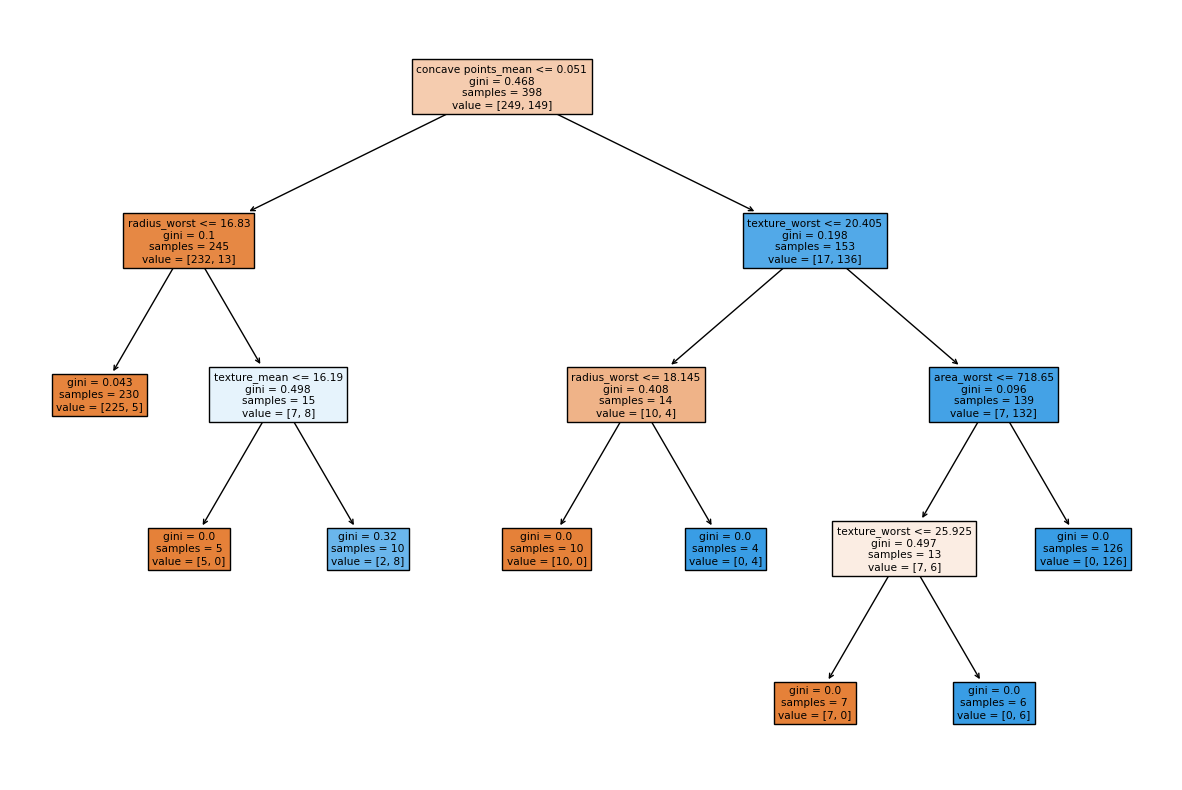

In [60]:
plt.figure(figsize=(15,10))
tree.plot_tree(clf, filled=True, feature_names = x.columns)

# XGBoost

In [61]:
xgb_clf = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
xgb_clf.fit(xtrain, ytrain)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, predictor=None, random_state=42, ...)

In [62]:
xgb_preds = xgb_clf.predict(xtest)
print("XGBoost Accuracy:", accuracy_score(ytest, xgb_preds))

XGBoost Accuracy: 0.9824561403508771


# CatBoost

In [63]:
cat_clf = CatBoostClassifier(verbose=0, random_state=42)
cat_clf.fit(xtrain, ytrain)

In [64]:
cat_preds = cat_clf.predict(xtest)
print("CatBoost Accuracy:", accuracy_score(ytest, cat_preds))

CatBoost Accuracy: 0.9766081871345029


# LightGBM Classifier

In [65]:
lgbm_clf = LGBMClassifier(random_state=42)
lgbm_clf.fit(xtrain, ytrain)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 149, number of negative: 249
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000820 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3978
[LightGBM] [Info] Number of data points in the train set: 398, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.374372 -> initscore=-0.513507
[LightGBM] [Info] Start training from score -0.513507
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

LGBMClassifier(random_state=42)

In [66]:
lgbm_preds = lgbm_clf.predict(xtest)
print("LightGBM Accuracy:", accuracy_score(ytest, lgbm_preds))

LightGBM Accuracy: 0.9473684210526315


In [67]:
accuracy_scores = {
    "XGBoost": accuracy_score(ytest, xgb_preds),
    "CatBoost": accuracy_score(ytest, cat_preds),
    "LightGBM": accuracy_score(ytest, lgbm_preds)
}

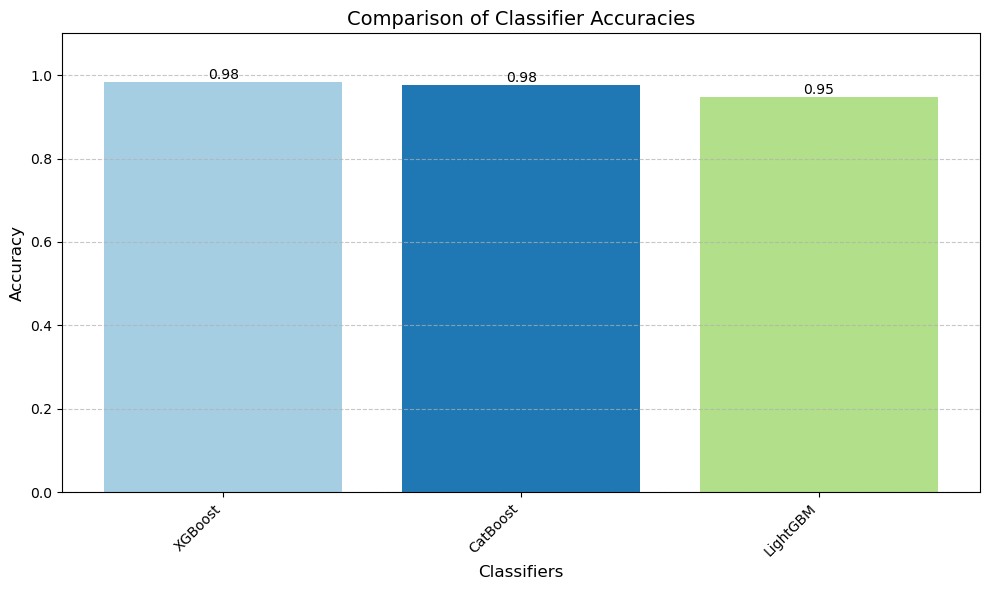

In [68]:
plt.figure(figsize=(10, 6))
colors = plt.cm.Paired(np.arange(len(accuracy_scores)))  # Used a colormap for different bar colors
bars = plt.bar(accuracy_scores.keys(), accuracy_scores.values(), color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.2f}', ha='center', va='bottom', fontsize=10)

plt.xlabel('Classifiers', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Comparison of Classifier Accuracies', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1)  # Extend limit slightly above 1 for better visibility of text
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()